# Importing Standard Libraries

In [846]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and Inspect Dataset


In [847]:
from sklearn.datasets import fetch_openml
dataset = fetch_openml(data_id=43463)

In [848]:
print(dataset.feature_names)

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [849]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)

In [850]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [851]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Handlind missing values and duplicate entries (if any)

In [852]:
# Check for missing values
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [853]:
# Drop missing values (if any)
df.dropna(inplace=True)

In [854]:
# Check for duplicate entries
df.duplicated().sum()

np.int64(1)

In [855]:
# Remove duplicates (if any)
df.drop_duplicates(inplace=True)

Converting categorical columns to numerical

In [856]:
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['sex', 'smoker', 'region'], dtype='object')


In [857]:
# Label encoding for the columns 'sex' and 'smoker'
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['sex'] = label_encoder.fit_transform(df['sex'])
df['smoker'] = label_encoder.fit_transform(df['smoker'])

In [858]:
# One hot encoding for the 'region' column
df = pd.get_dummies(df, columns=['region'], dtype=int)

Observe dataset now

In [859]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


In [860]:
X = df.drop('charges', axis=1)
y = df['charges']

# Dataset Splitting

In [861]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.3,random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.5,random_state=42)

In [862]:
# Convert to numpy arrays
X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

In [863]:
print("Shape of X_train:",X_train.shape)
print("Shape of X_test",X_test.shape)
print("Shape of X_val",X_val.shape)

print("Shape of y_train",y_train.shape)
print("Shape of y_test",y_test.shape)
print("Shapeof y_val",y_val.shape)

Shape of X_train: (935, 9)
Shape of X_test (201, 9)
Shape of X_val (201, 9)
Shape of y_train (935,)
Shape of y_test (201,)
Shapeof y_val (201,)


# Feature Preprocessing

In [864]:
# standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Categorical features already encoded in previous steps

# Scratch Implementation of Feedforward Neural Network for Regression

In [865]:
# Scaling y for better training, Will use inverse transform to get the final predicted values
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1,1))
y_val_scaled = y_scaler.transform(y_val.reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1,1))

In [866]:
class FeedforwardNN:
    # hidden_layers = [neurons per hidden layer]
    def __init__(self, input_size, hidden_layers, output_size=1, lr=0.01, epochs=2000, batch_size=32):
        self.lr = lr # learning rate
        self.epochs = epochs # number of epochs
        self.batch_size = batch_size # batch size for batch gradient descent
        self.layers = [input_size] + hidden_layers + [output_size] # list of neural network as layers
        self.weights = [] # to store weights for all layers
        self.biases = [] # to store biases for all layers
        np.random.seed(42) # initialize random state

        for i in range(len(self.layers)-1):
            self.weights.append(np.random.randn(self.layers[i], self.layers[i+1]) * 0.01) # initialize weights for all layers
            self.biases.append(np.zeros((1, self.layers[i+1]))) # initialize biase for all layers

    def relu(self, z): # relu activation function
        return np.maximum(0, z)

    def relu_derivative(self, a): # derivative of relu function for back propagation
        return (a > 0).astype(float)

    def forward(self, X): # forward pass

        a = X # input to first layer
        activations = [X] # stores output of each layer
        Z = [] # stores pre activation values w.a + b

        for i in range(len(self.weights)-1): # looping through all hidden layers
            z = np.dot(a, self.weights[i]) + self.biases[i]
            Z.append(z)
            a = self.relu(z)
            activations.append(a)

        # Output layer (linear activation)
        z = np.dot(a, self.weights[-1]) + self.biases[-1]
        Z.append(z)
        activations.append(z)
        return activations, Z

    def compute_loss(self, y_true, y_pred): # Calculating Mean squared Error
        return np.mean((y_true - y_pred)**2)

    def backward(self, activations, Z, y): # Backward pass

        grads_w = [0]*len(self.weights) # stores grad_w for ech layer
        grads_b = [0]*len(self.biases) # stores grad_b for each layer
        m = y.shape[0] # batch size

        # calculate gradient for output layer
        dz = (activations[-1] - y)
        grads_w[-1] = np.dot(activations[-2].T, dz)/m
        grads_b[-1] = np.sum(dz, axis=0, keepdims=True)/m

        # gradient calculations for hidden layers
        for i in reversed(range(len(self.weights)-1)):
            dz = np.dot(dz, self.weights[i+1].T) * self.relu_derivative(activations[i+1]) # gradient of loss wrt activation of next layer
            grads_w[i] = np.dot(activations[i].T, dz)/m
            grads_b[i] = np.sum(dz, axis=0, keepdims=True)/m
        return grads_w, grads_b

    def fit(self, X, y, X_val=None, y_val=None): # Training
        y = y.reshape(-1,1)
        if y_val is not None:
            y_val = y_val.reshape(-1,1)
        n_samples = X.shape[0]
        self.train_loss_history = []
        self.val_loss_history = []

        for epoch in range(self.epochs):
            # Shuffle the dataset in each epoch for mini batch gradient descent
            idx = np.random.permutation(n_samples)
            X_shuff = X[idx]
            y_shuff = y[idx]

            # Mini batch gradient descent
            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                X_batch = X_shuff[start:end]
                y_batch = y_shuff[start:end]

                # Forward and backward pass
                activations, Z = self.forward(X_batch)
                grads_w, grads_b = self.backward(activations, Z, y_batch)

                # Update weights and biases
                for i in range(len(self.weights)):
                    self.weights[i] -= self.lr * grads_w[i]
                    self.biases[i] -= self.lr * grads_b[i]

            # Record losses
            y_train_pred = self.predict(X)
            train_loss = self.compute_loss(y, y_train_pred)
            self.train_loss_history.append(train_loss)
            if X_val is not None and y_val is not None:
                y_val_pred = self.predict(X_val)
                val_loss = self.compute_loss(y_val, y_val_pred)
                self.val_loss_history.append(val_loss)

            if (epoch+1) % 100 == 0:
                val_loss_print = self.val_loss_history[-1] if X_val is not None else float('nan')
                print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_print:.4f}")

    def predict(self, X): # predict
        activations, _ = self.forward(X)
        return activations[-1]


In [867]:
# Train model
nn = FeedforwardNN(input_size=X_train.shape[1], hidden_layers=[64,32],lr=0.01, epochs=2000, batch_size=32)
nn.fit(X_train, y_train_scaled)

Epoch 100, Train Loss: 0.9780, Val Loss: nan
Epoch 200, Train Loss: 0.1683, Val Loss: nan
Epoch 300, Train Loss: 0.1512, Val Loss: nan
Epoch 400, Train Loss: 0.1452, Val Loss: nan
Epoch 500, Train Loss: 0.1412, Val Loss: nan
Epoch 600, Train Loss: 0.1382, Val Loss: nan
Epoch 700, Train Loss: 0.1358, Val Loss: nan
Epoch 800, Train Loss: 0.1339, Val Loss: nan
Epoch 900, Train Loss: 0.1313, Val Loss: nan
Epoch 1000, Train Loss: 0.1284, Val Loss: nan
Epoch 1100, Train Loss: 0.1259, Val Loss: nan
Epoch 1200, Train Loss: 0.1247, Val Loss: nan
Epoch 1300, Train Loss: 0.1221, Val Loss: nan
Epoch 1400, Train Loss: 0.1202, Val Loss: nan
Epoch 1500, Train Loss: 0.1179, Val Loss: nan
Epoch 1600, Train Loss: 0.1161, Val Loss: nan
Epoch 1700, Train Loss: 0.1154, Val Loss: nan
Epoch 1800, Train Loss: 0.1121, Val Loss: nan
Epoch 1900, Train Loss: 0.1098, Val Loss: nan
Epoch 2000, Train Loss: 0.1081, Val Loss: nan


# Hyperparameter Tuning

In [868]:
best_val_loss = float('inf')
best_params = None

lr = 0.01
batch_size = 32
epochs = 1000
for num_layers in [2,3]:
    for neurons in [32,64,128]:
        hidden_layers = [neurons]*num_layers
        print(f"Training NN with hidden layers: {hidden_layers}")

        nn = FeedforwardNN(input_size=X_train.shape[1], hidden_layers=hidden_layers, lr=lr, epochs=epochs, batch_size=batch_size)
        nn.fit(X_train, y_train_scaled, X_val, y_val_scaled)

        val_loss = nn.val_loss_history[-1]
        print(f"Validation Loss: {val_loss:.4f}\n")

        # Keep track of best
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = hidden_layers


Training NN with hidden layers: [32, 32]
Epoch 100, Train Loss: 0.9995, Val Loss: 1.2723
Epoch 200, Train Loss: 0.2224, Val Loss: 0.2391
Epoch 300, Train Loss: 0.1564, Val Loss: 0.1857
Epoch 400, Train Loss: 0.1501, Val Loss: 0.1858
Epoch 500, Train Loss: 0.1462, Val Loss: 0.1858
Epoch 600, Train Loss: 0.1431, Val Loss: 0.1859
Epoch 700, Train Loss: 0.1407, Val Loss: 0.1860
Epoch 800, Train Loss: 0.1386, Val Loss: 0.1848
Epoch 900, Train Loss: 0.1368, Val Loss: 0.1851
Epoch 1000, Train Loss: 0.1350, Val Loss: 0.1862
Validation Loss: 0.1862

Training NN with hidden layers: [64, 64]
Epoch 100, Train Loss: 0.9408, Val Loss: 1.2048
Epoch 200, Train Loss: 0.1619, Val Loss: 0.1858
Epoch 300, Train Loss: 0.1491, Val Loss: 0.1798
Epoch 400, Train Loss: 0.1429, Val Loss: 0.1784
Epoch 500, Train Loss: 0.1396, Val Loss: 0.1778
Epoch 600, Train Loss: 0.1369, Val Loss: 0.1766
Epoch 700, Train Loss: 0.1345, Val Loss: 0.1752
Epoch 800, Train Loss: 0.1318, Val Loss: 0.1727
Epoch 900, Train Loss: 0.129

In [869]:
print(f"Best hyperparameters: {best_params[0]} hidden layers, {best_params[1]} neurons per layer")
print(f"Validation MSE for best model: {best_val_loss:.4f}")

Best hyperparameters: 64 hidden layers, 64 neurons per layer
Validation MSE for best model: 0.1737


# Training and Validation Loss vs Epochs for best hyperparameters

In [870]:
best_hidden_layers = best_params

# Initialize NN with full training epochs
nn_best = FeedforwardNN(input_size=X_train.shape[1], hidden_layers=best_hidden_layers,lr=0.01, epochs=1000, batch_size=32)

# Train on training set while keeping track of validation loss
nn_best.fit(X_train, y_train_scaled, X_val, y_val_scaled)


Epoch 100, Train Loss: 0.9408, Val Loss: 1.2048
Epoch 200, Train Loss: 0.1619, Val Loss: 0.1858
Epoch 300, Train Loss: 0.1491, Val Loss: 0.1798
Epoch 400, Train Loss: 0.1429, Val Loss: 0.1784
Epoch 500, Train Loss: 0.1396, Val Loss: 0.1778
Epoch 600, Train Loss: 0.1369, Val Loss: 0.1766
Epoch 700, Train Loss: 0.1345, Val Loss: 0.1752
Epoch 800, Train Loss: 0.1318, Val Loss: 0.1727
Epoch 900, Train Loss: 0.1297, Val Loss: 0.1738
Epoch 1000, Train Loss: 0.1275, Val Loss: 0.1737


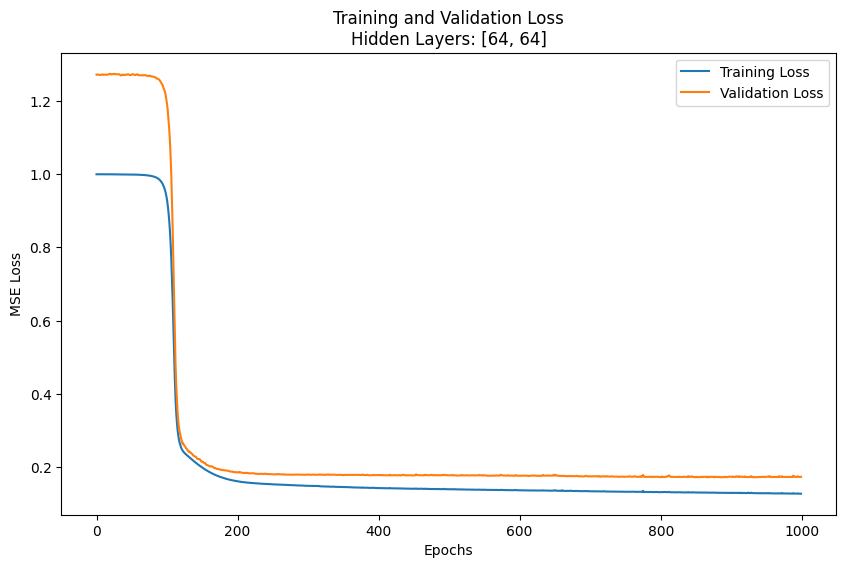

In [871]:
plt.figure(figsize=(10,6))
plt.plot(nn_best.train_loss_history, label='Training Loss')
plt.plot(nn_best.val_loss_history, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title(f"Training and Validation Loss\nHidden Layers: {best_hidden_layers}")
plt.legend()
plt.show()


# Model Evaluation - Custom NN

In [872]:
# Predict on test set
y_pred_scaled = nn_best.predict(X_test)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Test MSE: {mse:.2f}, R² Score: {r2:.4f}")

Test MSE: 23575137.16, R² Score: 0.8619


Scatter plot of predictions vs ground truth targets

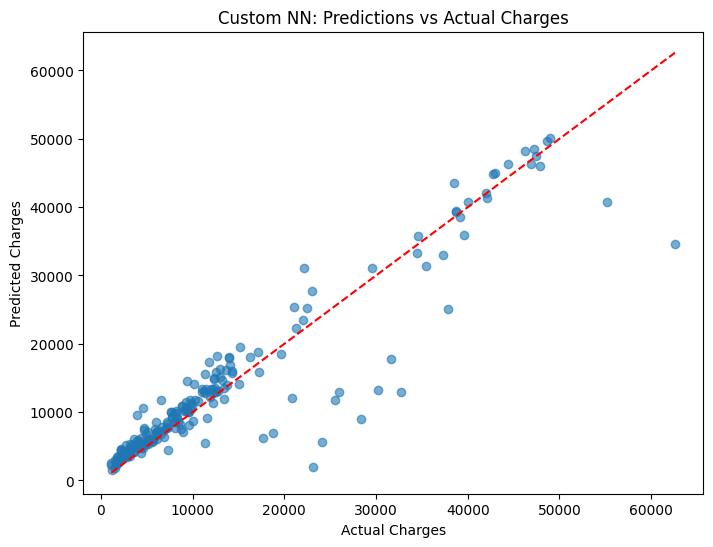

In [873]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Custom NN: Predictions vs Actual Charges")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # line depicting perfect predictions
plt.show()

# Sklearn Implementation

In [874]:
from sklearn.neural_network import MLPRegressor
# Using same best parameters
mlp = MLPRegressor(hidden_layer_sizes=best_hidden_layers, activation='relu', solver='adam', learning_rate_init=0.01, batch_size=32, max_iter=2000, random_state=42)

In [880]:
mlp.fit(X_train, y_train_scaled.ravel())

MLPRegressor(batch_size=32, hidden_layer_sizes=[64, 64],
             learning_rate_init=0.01, max_iter=2000, random_state=42)

In [881]:
y_pred_mlp_scaled = mlp.predict(X_test)
y_pred_mlp = y_scaler.inverse_transform(y_pred_mlp_scaled.reshape(-1,1))


In [882]:
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print(f"MLPRegressor Test MSE: {mse_mlp:.2f}")
print(f"MLPRegressor Test R² Score: {r2_mlp:.4f}")


MLPRegressor Test MSE: 29804329.79
MLPRegressor Test R² Score: 0.8254


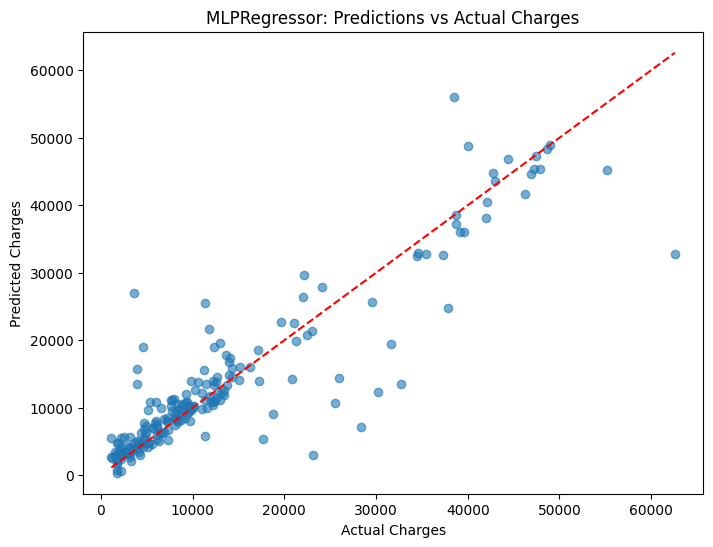

In [883]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_mlp, alpha=0.6)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("MLPRegressor: Predictions vs Actual Charges")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # line depicting perfect predictions
plt.show()

In [884]:
print(f"Custom NN R²: {r2:.4f}, MLPRegressor R²: {r2_mlp:.4f}")
print(f"Custom NN MSE: {mse:.2f}, MLPRegressor MSE: {mse_mlp:.2f}")

Custom NN R²: 0.8619, MLPRegressor R²: 0.8254
Custom NN MSE: 23575137.16, MLPRegressor MSE: 29804329.79
